In [164]:
from functions import *

import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
import statsmodels.api as sm

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import os
#Caminho para dados dos aglomerados
path = './Aglomerados/'

import warnings
warnings.filterwarnings('ignore')

In [165]:
df =pd.read_csv('Dados/results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv('Dados/benchmark_subsample.csv', index_col='Cluster')

print('full sample description')
print(df[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members', 'bin_frac','e_bin_frac']].describe().round(2).T)

print('\nBenchmark subsample description')
print(benchmark_subsample[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members' , 'bin_frac', 'e_bin_frac']].describe().round(2).T)


full sample description
            count    mean     std    min     25%     50%     75%      max
dist        771.0    1.75    1.00   0.14    0.94    1.64    2.37     6.87
age         771.0    8.18    0.64   6.67    7.79    8.25    8.68     9.59
FeH         771.0   -0.04    0.11  -0.37   -0.11   -0.04    0.03     0.43
Av          771.0    1.41    0.79   0.01    0.81    1.38    1.92     4.49
mass_total  771.0  544.47  447.32  61.00  245.00  413.00  678.00  3434.00
n_members   771.0  311.12  240.91  42.00  147.00  242.00  394.00  1548.00
bin_frac    771.0    0.58    0.11   0.23    0.51    0.58    0.66     0.90
e_bin_frac  771.0    0.06    0.04   0.01    0.04    0.05    0.08     0.25

Benchmark subsample description
            count    mean     std    min     25%     50%     75%      max
dist         94.0    0.63    0.29   0.14    0.39    0.61    0.79     1.37
age          94.0    8.24    0.57   6.74    7.80    8.31    8.63     9.58
FeH          94.0   -0.02    0.08  -0.23   -0.06   -0.0

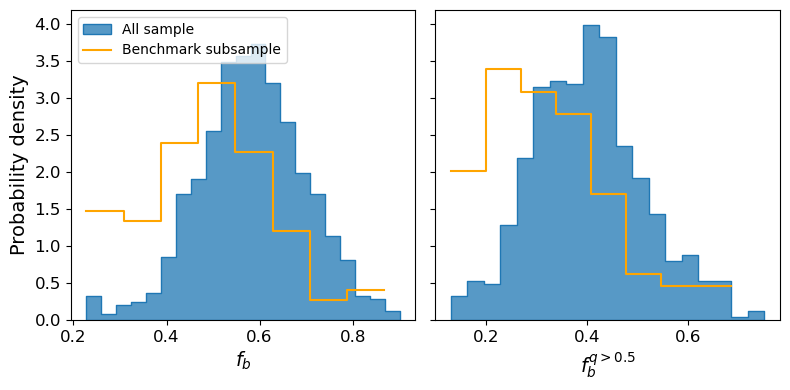

In [229]:
fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)

sns.histplot(data=df, x='bin_frac', element='step', stat='density', ax=axs[0], label='All sample')
sns.histplot(data=benchmark_subsample, x='bin_frac', element='step', stat='density', fill=False, ax=axs[0], color='orange',
            label='Benchmark subsample')

med_df = df.bin_frac.median()
med_bench = benchmark_subsample.bin_frac.median()



sns.histplot(data=df, x='bin_frac_0.5', element='step', stat='density',ax=axs[1],  legend=False)
sns.histplot(data=benchmark_subsample, x='bin_frac_0.5', element='step', stat='density', fill=False, ax=axs[1], color='orange', legend=False)



axs[0].tick_params(labelsize=labelsize)
axs[1].tick_params(labelsize=labelsize)
axs[0].set_xlabel(r'$f_b$', fontdict=font)
axs[0].set_ylabel('Probability density', fontdict=font)
axs[1].set_xlabel(r'$f_b^{q>0.5}$', fontdict=font)


axs[0].legend(loc = 'upper left')

plt.tight_layout()
plt.savefig('Figures/dist_fb.png',bbox_inches='tight', dpi=300)
plt.show()




In [230]:
benchmark_subsample[['bin_frac','bin_frac_0.5']].describe()

,bin_frac,bin_frac_0.5
count,94.000000,94.000000
mean,0.491278,0.326600
std,0.142073,0.119974
min,0.227915,0.131488
25%,0.406183,0.246006
50%,0.500000,0.299299
75%,0.600627,0.403405
max,0.867925,0.683616


In [102]:
df[df['bin_frac']>0.85][['dist', 'Av','age','FeH',]]

,dist,Av,age,FeH
Cluster,,,,
Bica_2,1.588,4.486,6.673,0.059
FSR_0977,1.781,1.595,8.930,-0.147
NGC_2509,2.831,0.055,9.146,0.426
Pismis_11,2.211,3.411,6.833,0.006
UBC_433,4.048,1.863,9.106,-0.306
UPK_24,0.498,1.349,8.736,-0.373
UPK_54,0.798,1.252,8.305,-0.188
UPK_585,0.703,0.446,8.451,-0.233


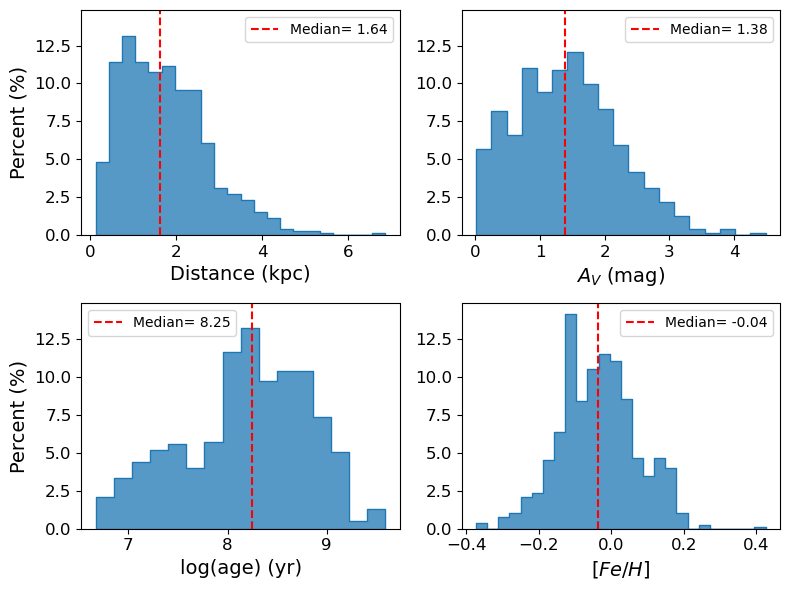

In [3]:
fig, axs = plt.subplots(2,2, figsize = (8,6), sharey=True)

sns.histplot(data=df, x='dist', ax = axs[0,0], stat='percent', element='step',)
axs[0,0].set_xlabel('Distance (kpc)', fontdict=font)
axs[0,0].axvline(x=df['dist'].median(), color='r',ls='--',  label = f'Median= {df.dist.median():.2f}')
axs[0,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 0].legend()


sns.histplot(data=df, x='Av', ax = axs[0,1], stat='percent', element='step')
axs[0,1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0,1].axvline(x=df['Av'].median(), color='r',ls='--', label = f'Median= {df.Av.median():.2f}')
axs[0,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 1].legend()

sns.histplot(data=df, x='age', ax = axs[1,0], stat='percent', element='step')
axs[1,0].set_xlabel('log(age) (yr)', fontdict=font)
axs[1,0].axvline(x=df['age'].median(), color='r',ls='--', label = f'Median= {df.age.median():.2f}')
axs[1,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1, 0].legend()

sns.histplot(data=df, x='FeH', ax = axs[1,1], stat='percent', element='step')
axs[1,1].set_xlabel(r'[$Fe/H$]', fontdict=font)
axs[1,1].axvline(x=df['FeH'].median(), color='r',ls='--', label = f'Median= {df.FeH.median():.2f}')
axs[1,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1,1].legend()

axs[0,0].set_ylabel('Percent (%)', fontdict=font)
axs[1,0].set_ylabel('Percent (%)', fontdict=font)



plt.tight_layout()
plt.savefig('Figures/clusters_properties.png',bbox_inches='tight', dpi=300)
plt.show()

In [126]:
print(df[['bin_frac','e_bin_frac','bin_frac_0.5','e_bin_frac_0.5']].describe().round(2).T)

                count  mean   std   min   25%   50%   75%   max
bin_frac        771.0  0.58  0.11  0.23  0.51  0.58  0.66  0.90
e_bin_frac      771.0  0.15  0.07  0.03  0.09  0.13  0.18  0.46
bin_frac_0.5    771.0  0.40  0.11  0.13  0.32  0.40  0.47  0.75
e_bin_frac_0.5  771.0  0.15  0.08  0.02  0.09  0.13  0.19  0.42


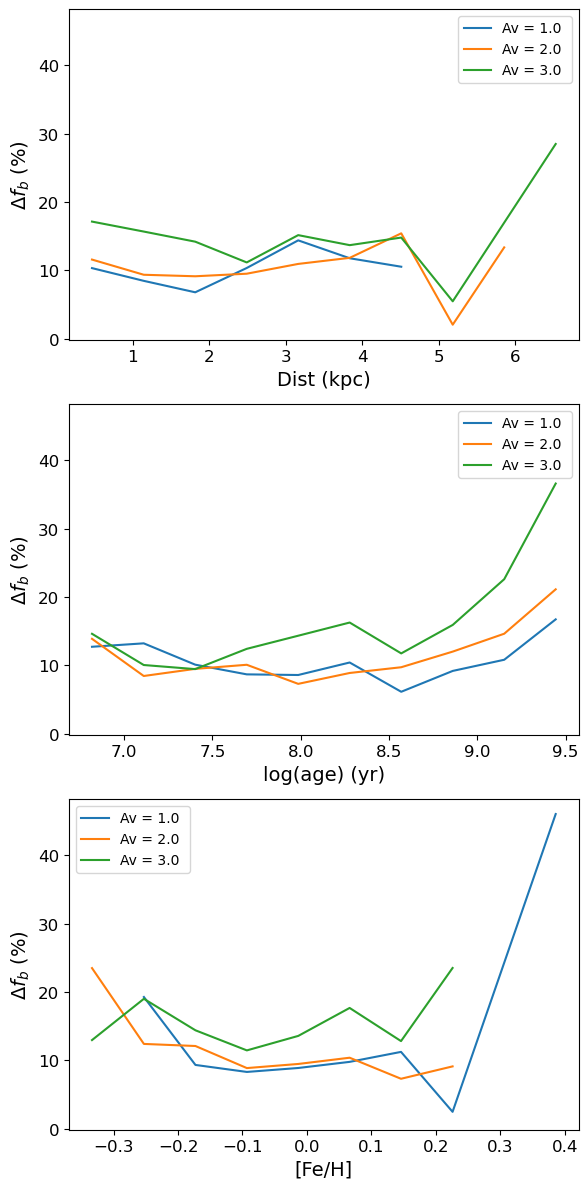

In [183]:
fig, axs = plt.subplots(3,1, figsize = (6,12), sharey=True)
aux = df.copy(deep=True)

# Agrupamento por faixas de extinção Av
aux['Av_group'] = pd.cut(aux['Av'], bins=[0, 1.0, 2.0, 3.0], labels=['Av = 1.0 ', 'Av = 2.0', 'Av = 3.0',])
aux['delta_fb'] = np.abs(aux['bin_frac'] - aux['bin_frac_ref'])


#Plot da distância
aux['dist_bin'] = pd.cut(aux['dist'], bins=10)
aux['dist_center'] = aux['dist_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'dist_center'])['delta_fb'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='dist_center', y=grouped['mean']*100, hue='Av_group', ax= axs[0])
axs[0].set_xlabel(r'Dist (kpc)', fontdict=font)


#Plot da idade
aux['age_bin'] = pd.cut(aux['age'], bins=10)
aux['age_center'] = aux['age_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'age_center'])['delta_fb'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='age_center', y=grouped['mean']*100, hue='Av_group', ax= axs[1])
axs[1].set_xlabel(r'log(age) (yr)', fontdict=font)

#Plot metalicidade
aux['FeH_bin'] = pd.cut(aux['FeH'], bins=10)
aux['FeH_center'] = aux['FeH_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'FeH_center'])['delta_fb'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='FeH_center', y=grouped['mean']*100, hue='Av_group', ax= axs[2])
axs[2].set_xlabel(r'[Fe/H]', fontdict=font)

axs[0].set_ylabel(r'$\Delta{f_b}$ (%)', fontdict= font)
axs[1].set_ylabel(r'$\Delta{f_b}$ (%)', fontdict= font)
axs[2].set_ylabel(r'$\Delta{f_b}$ (%)', fontdict= font)

for ax in axs:
    ax.tick_params(labelsize=labelsize)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('Figures/delta_fb.png',bbox_inches='tight', dpi=300)
plt.show()


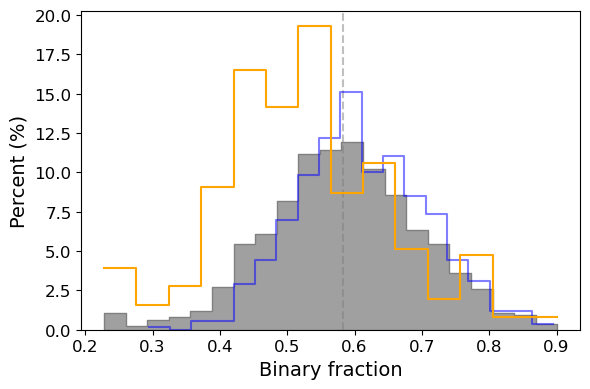

In [31]:
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(data=df, x='bin_frac', stat='percent', element='step', color='gray',)
plt.axvline(df.bin_frac.median(), ls='--', c='gray', alpha=0.5)
sns.histplot(data=df[df.Av>1], x='bin_frac', stat='percent', element='step', color='blue', fill = False, alpha=0.5)
sns.histplot(data=df[df.Av<=1], x='bin_frac', stat='percent', element='step', color='orange', fill = False,)

plt.xlabel('Binary fraction', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('Figures/dist_fb.png',  dpi=300)
plt.show()


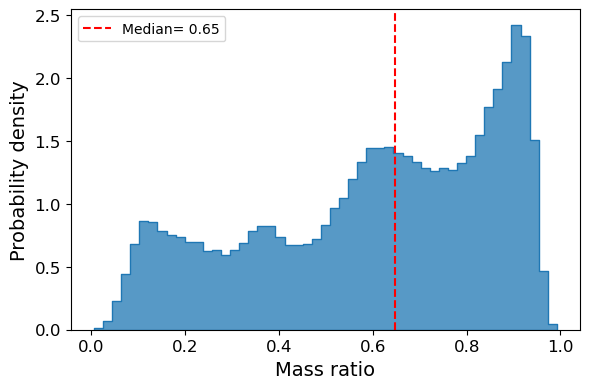

In [232]:
data = pd.read_csv('Dados/data.csv', index_col='Cluster')
    
median = data[data.q>0]['q'].median()
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(x=data[data.q>0]['q'], stat='density', element='step')
plt.axvline(data[data.q>0]['q'].median(), ls='--', c='r', 
            label = f'Median= {median:.2f}')

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Probability density', fontdict=font)
ax.tick_params(labelsize=labelsize)
plt.tight_layout()
plt.legend(loc='upper left')
plt.savefig('Figures/dist_mass_ratio.png',  dpi=300)
plt.show()

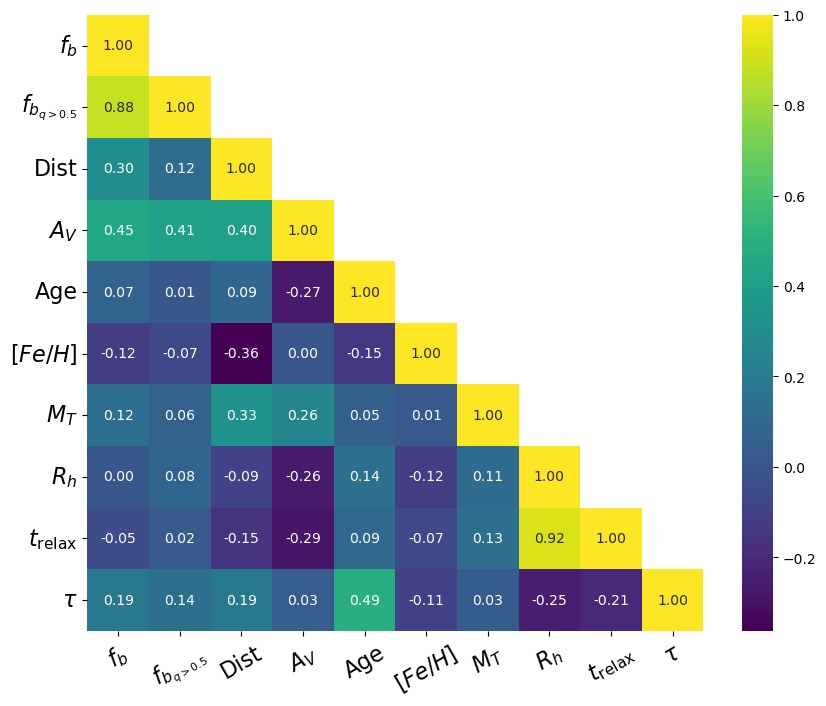

In [104]:
nome_vars = {
    'bin_frac': r'$f_b$',
    'bin_frac_0.5': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = df[cols].corr()
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(10, 8))
cmap = palette 

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(30) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

#plt.savefig('Figures/corr.png',bbox_inches='tight')
plt.show()

In [103]:
df

,RA_ICRS,DE_ICRS,dist,e_dist,age,e_age,Av,e_Av,FeH,e_FeH,...,bin_frac,e_bin_frac,bin_frac_0.5,e_bin_frac_0.5,average_ratio,str_average_ratio,segr_ratio,segr_ratio_std,mass_seg,mass_seg_pval
Cluster,,,,,,,,,,,,,,,,,,,,,
ASCC_10,51.9055,35.0110,0.642,0.003,8.292,0.088,0.793,0.068,0.004,0.028,...,0.458716,0.048415,0.256881,0.032670,0.51823,0.26538,1.53993,6.46874,0.34689,0.00332
ASCC_105,295.5766,27.4244,0.552,0.002,8.117,0.053,0.765,0.006,-0.252,0.066,...,0.785714,0.228653,0.615385,0.211924,0.70889,0.21848,1.12542,5.59048,0.21638,0.05084
ASCC_107,297.1882,21.9844,0.847,0.008,7.652,0.359,1.463,0.204,0.253,0.187,...,0.796296,0.280989,0.657407,0.321867,0.78835,0.22252,1.30286,3.00649,0.37446,0.00101
ASCC_108,298.4716,39.2269,1.157,0.003,8.241,0.071,0.655,0.050,-0.097,0.033,...,0.556522,0.136609,0.363478,0.123787,0.59206,0.24218,1.04515,14.36767,0.11909,0.03634
ASCC_11,53.0538,44.8967,0.826,0.005,8.443,0.194,0.975,0.101,-0.121,0.044,...,0.495468,0.057609,0.359517,0.069227,0.60459,0.23087,1.26139,7.17919,0.13528,0.11318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UPK_93,300.1772,30.0312,0.637,0.040,8.766,0.092,0.410,0.097,-0.228,0.043,...,0.804124,0.387231,0.546392,0.291373,0.62499,0.22171,1.18673,4.05038,0.29273,0.04022
UPK_94,304.7675,27.5894,0.933,0.012,8.626,0.181,1.211,0.077,-0.040,0.071,...,0.661538,0.087693,0.461538,0.146854,0.60853,0.24127,1.06023,4.44106,0.35835,0.03257
vdBergh_130,304.4921,39.3298,1.559,0.123,6.742,0.129,2.450,0.030,0.051,0.157,...,0.595238,0.093079,0.500000,0.162970,0.78906,0.22047,1.18079,0.92851,0.23931,0.10686


In [124]:
df[df['dist']<1][['dist','age', 'FeH', 'Av', 'mass_total', 'n_members', 'bin_frac','e_bin_frac']].describe()

,dist,age,FeH,Av,mass_total,n_members,bin_frac,e_bin_frac
count,209.000000,209.000000,209.000000,209.000000,209.00000,209.000000,209.000000,209.000000
mean,0.668847,8.170450,-0.029742,0.861211,309.54067,280.090909,0.548408,0.159489
std,0.213441,0.551092,0.099585,0.675987,232.05323,209.789813,0.143602,0.073813
min,0.135000,6.693000,-0.373000,0.010000,61.00000,42.000000,0.227915,0.032808
25%,0.534000,8.000000,-0.078000,0.325000,155.00000,119.000000,0.447917,0.106657
50%,0.692000,8.274000,-0.031000,0.727000,244.00000,224.000000,0.545455,0.145033
75%,0.848000,8.517000,0.025000,1.237000,379.00000,371.000000,0.659878,0.196267
max,0.994000,9.578000,0.253000,3.753000,1843.00000,1548.000000,0.875000,0.409227
